# Rapport analytique — Base IRVE

Ce notebook répond à trois questions métier à partir des collections `stations`
et `statuts_pdc` chargées sur MongoDB Atlas.

Les pipelines ne sont pas écrits ici : ils vivent dans le module réutilisable
[`src/queries.py`](../src/queries.py), pour être partagés entre ce notebook,
l'interface Streamlit et les mesures d'index. Le notebook sert à exécuter,
visualiser et interpréter.

**Les trois questions traitées :**

1. Quels territoires sont les mieux équipés, et la puissance y est-elle comparable ?
2. Quels opérateurs dominent le réseau, et déploient-ils la même qualité de service ?
3. À quel rythme le réseau s'est-il déployé depuis 2018 ?

Une quatrième section exploite le snapshot dynamique, et une cinquième
démontre la recherche géospatiale.

In [1]:
import sys
from pathlib import Path

# Le notebook vit dans analysis/ : on ajoute la racine au path pour importer src.
RACINE = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
if str(RACINE) not in sys.path:
    sys.path.insert(0, str(RACINE))

import pandas as pd
import matplotlib.pyplot as plt

from src.database import connexion
from src.queries import (
    offre_par_departement,
    puissance_par_departement,
    top_operateurs,
    evolution_annuelle,
    etat_parc,
    pipeline_top_operateurs,
    pipeline_stations_proches_avec_distance,
)
from src.config import COLLECTION_STATIONS

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

client, db = connexion()
print(f"Connexion OK - base : {db.name}")
print(f"stations    : {db[COLLECTION_STATIONS].count_documents({}):,}")

Connexion OK - base : irve
stations    : 48,040


## 1. Quels territoires sont les mieux équipés ?

On mesure d'abord le volume par département, puis la puissance moyenne, car les
deux ne racontent pas la même histoire : un territoire peut concentrer beaucoup
de points de recharge lents, ou peu de bornes mais très puissantes.

In [2]:
df_dept = pd.DataFrame(offre_par_departement(db, limite=15))
df_dept

,nb_stations,nb_pdc,departement
0,581,5905,75
1,1325,5153,59
2,964,4627,33
3,784,3925,69
4,977,3619,13
5,799,3012,77
6,910,2938,78
7,766,2686,62
8,810,2556,44
9,862,2519,14


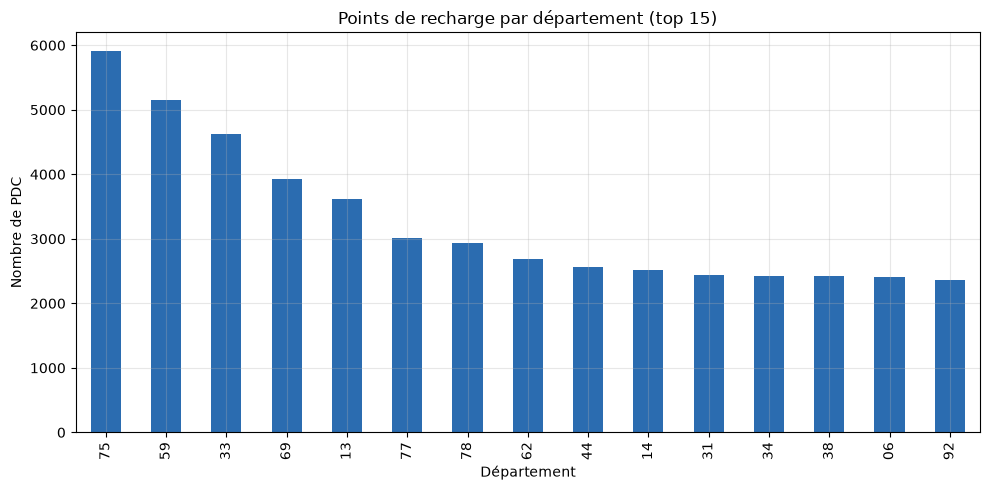

In [3]:
ax = df_dept.plot.bar(x="departement", y="nb_pdc", legend=False,
                      color="#2b6cb0", edgecolor="none")
ax.set_title("Points de recharge par département (top 15)")
ax.set_xlabel("Département")
ax.set_ylabel("Nombre de PDC")
plt.tight_layout()
plt.show()

Le pipeline exécuté ici somme le compteur `nbre_pdc` sans dérouler le tableau
embarqué. C'est volontaire : tant qu'on ne s'intéresse qu'au volume, `$unwind`
serait un coût inutile.

Pour la puissance moyenne en revanche, il faut descendre au niveau du PDC — donc
`$unwind` devient nécessaire.

In [4]:
df_puiss = pd.DataFrame(puissance_par_departement(db, limite=15))
df_puiss

,nb_pdc,puissance_max,departement,puissance_moyenne
0,5905,300.0,75,14.9
1,5150,600.0,59,70.4
2,4624,400.0,33,56.3
3,3920,600.0,69,58.5
4,3615,450.0,13,78.8
5,3011,480.0,77,75.9
6,2934,600.0,78,67.9
7,2684,400.0,62,77.0
8,2556,400.0,44,61.8
9,2517,600.0,14,69.9


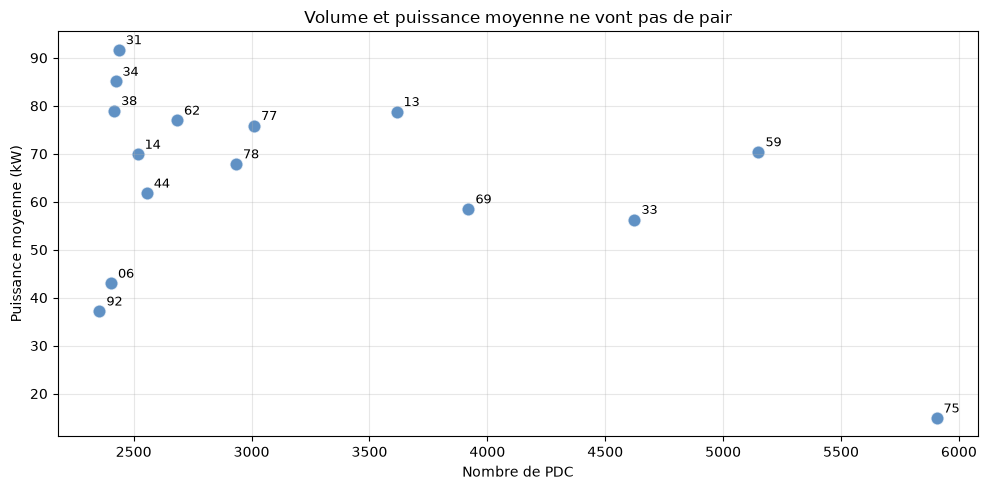

In [5]:
fig, ax = plt.subplots()
ax.scatter(df_puiss["nb_pdc"], df_puiss["puissance_moyenne"],
           s=90, color="#2b6cb0", alpha=0.75, edgecolor="white")
for _, r in df_puiss.iterrows():
    ax.annotate(r["departement"], (r["nb_pdc"], r["puissance_moyenne"]),
                xytext=(5, 4), textcoords="offset points", fontsize=9)
ax.set_title("Volume et puissance moyenne ne vont pas de pair")
ax.set_xlabel("Nombre de PDC")
ax.set_ylabel("Puissance moyenne (kW)")
plt.tight_layout()
plt.show()

**Lecture.** L'axe horizontal donne le volume, l'axe vertical la qualité de
l'offre. Un département situé en bas à droite est bien équipé en nombre mais
surtout en recharge lente ; en haut à gauche, l'inverse. C'est cette lecture
croisée qui a un intérêt métier, pas le classement brut.

## 2. Quels opérateurs dominent, et avec quelle qualité de service ?

Le classement par nombre de PDC seul serait trompeur. On calcule donc aussi la
part de recharge rapide (≥ 50 kW) de chaque opérateur, avec un `$cond` à
l'intérieur du `$group` : cela distingue un réseau de bornes 22 kW d'un réseau
de bornes autoroutières.

In [6]:
df_ope = pd.DataFrame(top_operateurs(db, limite=10))
df_ope

,nb_pdc,operateur,puissance_moyenne,part_rapide_pct
0,15012,Bouygues Energies & Services,22.8,4.4
1,11745,IZIVIA,55.3,29.1
2,9488,Freshmile | FR*FR1,25.7,6.9
3,7619,Power Dot France,103.5,78.0
4,7507,GROUPE INDIGO,7.7,0.0
5,6302,TotalEnergies Marketing France,84.1,35.0
6,5105,EASYCHARGE,36.1,22.8
7,4922,Allego,134.7,61.6
8,4912,Lidl France,66.2,38.4
9,4102,Tesla,236.9,100.0


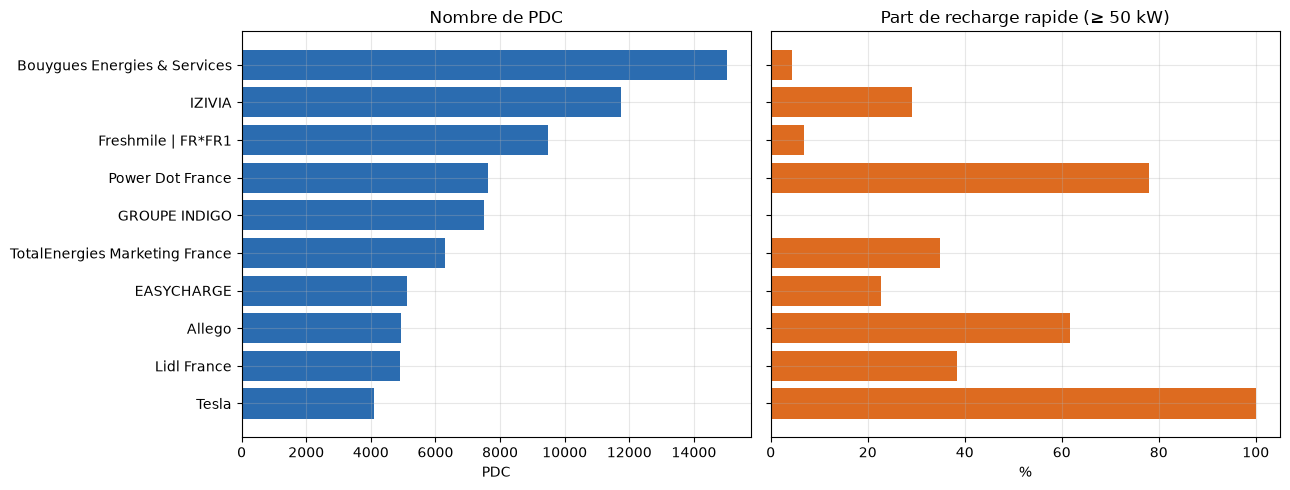

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))

a1.barh(df_ope["operateur"], df_ope["nb_pdc"], color="#2b6cb0")
a1.invert_yaxis()
a1.set_title("Nombre de PDC")
a1.set_xlabel("PDC")

a2.barh(df_ope["operateur"], df_ope["part_rapide_pct"], color="#dd6b20")
a2.invert_yaxis()
a2.set_yticklabels([])
a2.set_title("Part de recharge rapide (≥ 50 kW)")
a2.set_xlabel("%")

plt.tight_layout()
plt.show()

**Lecture.** Les deux graphiques se lisent ensemble : le premier donne la taille
du réseau, le second sa nature. Un opérateur peut être premier en volume tout en
étant dernier en part de recharge rapide — c'est exactement ce qu'un classement
à une seule colonne aurait masqué.

### Le pipeline exécuté

`src/queries.py` renvoie les pipelines sans les exécuter, ce qui permet de les
afficher tels quels.

In [8]:
import json
print(json.dumps(pipeline_top_operateurs(limite=10), indent=2, ensure_ascii=False))

[
  {
    "$match": {
      "operateur": {
        "$ne": null
      }
    }
  },
  {
    "$unwind": "$points_recharge"
  },
  {
    "$group": {
      "_id": "$operateur",
      "nb_pdc": {
        "$sum": 1
      },
      "puissance_moyenne": {
        "$avg": "$points_recharge.puissance_kw"
      },
      "nb_rapide": {
        "$sum": {
          "$cond": [
            {
              "$gte": [
                "$points_recharge.puissance_kw",
                50
              ]
            },
            1,
            0
          ]
        }
      }
    }
  },
  {
    "$sort": {
      "nb_pdc": -1
    }
  },
  {
    "$limit": 10
  },
  {
    "$project": {
      "_id": 0,
      "operateur": "$_id",
      "nb_pdc": 1,
      "puissance_moyenne": {
        "$round": [
          "$puissance_moyenne",
          1
        ]
      },
      "part_rapide_pct": {
        "$round": [
          {
            "$multiply": [
              {
                "$divide": [
                  "$nb_rapid

## 3. À quel rythme le réseau s'est-il déployé ?

Ici, **pas de `$unwind`** : on compte des stations, et chaque document *est*
déjà une station. Les PDC sont obtenus en sommant `nbre_pdc`. Dérouler
165 000 sous-documents pour un simple comptage annuel serait un gaspillage.

Le `$match` final écarte les années aberrantes : la source contient des dates de
mise en service manifestement erronées.

In [9]:
df_annee = pd.DataFrame(evolution_annuelle(db))
df_annee

,nb_stations,nb_pdc,annee
0,1,8,2012
1,2,6,2013
2,7,94,2014
3,38,102,2015
4,239,485,2016
5,491,912,2017
6,172,375,2018
7,1062,1705,2019
8,775,1972,2020
9,3579,9567,2021


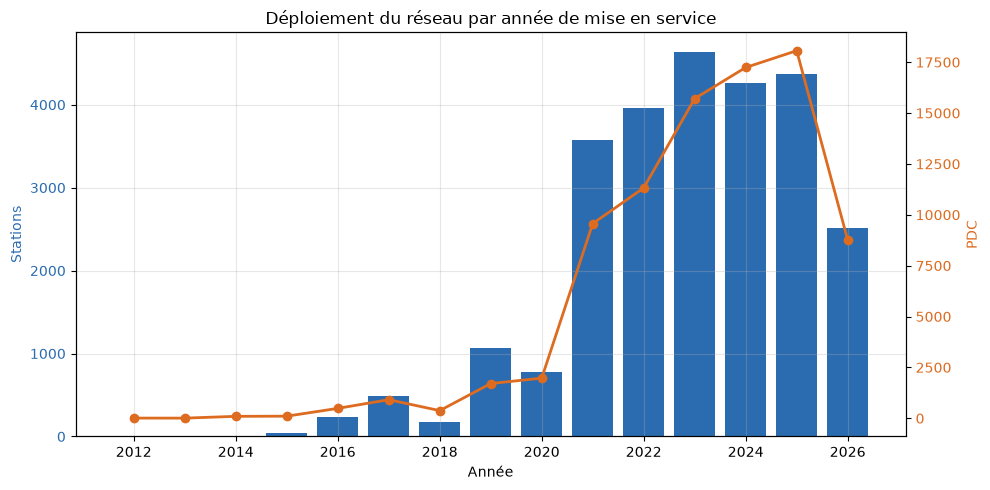

In [10]:
fig, ax1 = plt.subplots()
ax1.bar(df_annee["annee"], df_annee["nb_stations"], color="#2b6cb0",
        label="Stations mises en service")
ax1.set_xlabel("Année")
ax1.set_ylabel("Stations", color="#2b6cb0")
ax1.tick_params(axis="y", labelcolor="#2b6cb0")

ax2 = ax1.twinx()
ax2.plot(df_annee["annee"], df_annee["nb_pdc"], color="#dd6b20",
         marker="o", linewidth=2, label="PDC")
ax2.set_ylabel("PDC", color="#dd6b20")
ax2.tick_params(axis="y", labelcolor="#dd6b20")
ax2.grid(False)

plt.title("Déploiement du réseau par année de mise en service")
plt.tight_layout()
plt.show()

**Lecture.** La courbe des PDC suit les barres de stations : les stations
récentes ne sont pas systématiquement plus grandes que les anciennes.

**Limite à annoncer.** Ce graphique repose sur `date_mise_en_service`, un champ
déclaratif de la source. Les stations dont la date est absente ou invalide
n'apparaissent pas — la dernière année est également tronquée, l'export ne
couvrant pas l'année complète.

## 4. État du parc dans le snapshot dynamique

Cette section interroge `statuts_pdc`, notre seconde collection.

**Portée à rappeler :** le fichier dynamique est un instantané téléchargé à une
date donnée. Ces chiffres décrivent l'état du parc à ce moment-là, pas un état
temps réel.

In [11]:
df_etat = pd.DataFrame(etat_parc(db))
df_etat.head(10)

,nb_pdc,etat,occupation
0,76020,en_service,libre
1,12212,en_service,occupe
2,5608,hors_service,inconnu
3,2904,hors_service,libre
4,2531,inconnu,inconnu
5,1331,en_service,inconnu
6,152,hors_service,occupe
7,62,inconnu,libre
8,12,en_service,reserve
9,6,inconnu,occupe


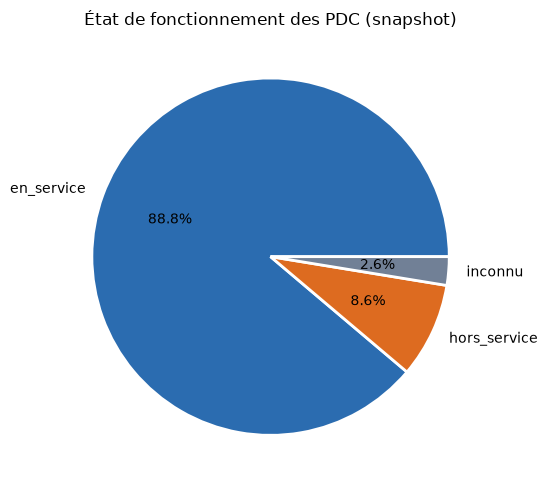

etat
en_service      89575
hors_service     8664
inconnu          2599


In [12]:
par_etat = df_etat.groupby("etat", dropna=False)["nb_pdc"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(par_etat.values, labels=par_etat.index, autopct="%1.1f%%",
       colors=["#2b6cb0", "#dd6b20", "#718096", "#38a169", "#e53e3e"],
       wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("État de fonctionnement des PDC (snapshot)")
plt.tight_layout()
plt.show()

print(par_etat.to_string())

## 5. Recherche géospatiale

Démonstration de l'index `2dsphere` : les stations les plus proches d'une
position, avec la distance calculée par `$geoNear`.

`$geoNear` doit être le premier étage du pipeline et exige l'index `2dsphere`
sur `localisation`.

In [13]:
# Place de la Concorde, Paris
LON, LAT = 2.3212, 48.8656

pipeline = pipeline_stations_proches_avec_distance(LON, LAT, rayon_metres=2000, limite=10)
proches = list(db[COLLECTION_STATIONS].aggregate(pipeline))

df_proches = pd.DataFrame([
    {
        "nom": s.get("nom"),
        "operateur": s.get("operateur"),
        "distance_m": s.get("distance_m"),
        "nbre_pdc": s.get("nbre_pdc"),
        "puissance_max_kw": max(
            (p.get("puissance_kw") or 0) for p in s.get("points_recharge", [])
        ) if s.get("points_recharge") else None,
    }
    for s in proches
])
print(f"{len(df_proches)} station(s) à moins de 2 km")
df_proches

10 station(s) à moins de 2 km


,nom,operateur,distance_m,nbre_pdc,puissance_max_kw
0,Paris | Avenue Dutuit 3,TotalEnergies Marketing France,420.0,3,22.00
1,Paris | boulevard Malesherbes 7,TotalEnergies Marketing France,566.0,6,7.00
2,Paris | boulevard de la Madeleine 8,TotalEnergies Marketing France,610.0,5,7.00
3,SAEMES - Parking Madeleine-Tronchet - Niveau 6,Bouygues Energies & Services,654.0,29,7.36
4,SAEMES - Parking Madeleine-Tronchet - Niveau 2,Bouygues Energies & Services,654.0,16,22.08
5,SAEMES - Parking Madeleine-Tronchet - Niveau 3,Bouygues Energies & Services,654.0,51,7.36
6,SAEMES - Parking Madeleine-Tronchet - Niveau 1,Bouygues Energies & Services,654.0,5,22.08
7,Paris | Rue de Bellechasse 5,TotalEnergies Marketing France,682.0,5,7.00
8,Vendôme,GROUPE INDIGO,696.0,56,22.00
9,Paris | Rue de Martignac 2,TotalEnergies Marketing France,705.0,6,7.00


## Synthèse

| Question | Pipeline | `$unwind` ? |
|---|---|---|
| Territoires les mieux équipés | `pipeline_offre_par_departement` | Non — somme de `nbre_pdc` |
| Puissance moyenne par territoire | `pipeline_puissance_par_departement` | Oui — moyenne au niveau PDC |
| Opérateurs et qualité de service | `pipeline_top_operateurs` | Oui — comptage PDC par PDC |
| Rythme de déploiement | `pipeline_evolution_annuelle` | Non — on compte des stations |
| État du parc | `pipeline_etat_parc` | Non — collection `statuts_pdc` |

**Ce que ces agrégations disent de notre modélisation.** `$unwind` n'apparaît
que lorsque l'analyse porte réellement sur le PDC. C'est le coût annoncé de
notre choix d'embarquement, et il reste circonscrit : dès que la question porte
sur la station, le compteur dénormalisé `nbre_pdc` permet de l'éviter.

**Limites assumées :**

- `date_mise_en_service` est déclarative et parfois absente ou aberrante ;
- environ 16 % des coordonnées ne sont pas validées par la source et sont
  exclues de l'index géospatial : ces stations n'apparaissent dans aucune
  recherche de proximité ;
- le snapshot dynamique ne couvre qu'une partie des PDC statiques et ne
  constitue pas un flux temps réel.

In [14]:
client.close()
print("Connexion fermée.")

Connexion fermée.
